# Give Me Some Credit — 逻辑回归实战

**目标**：根据借款人的信用特征，预测其未来两年内发生严重逾期（违约）的**概率**（二分类）。

**业务场景**：银行 / 互金风控。**监管要求模型可解释**——必须知道为什么拒绝客户，而**逻辑回归是合规首选模型**。

**技术栈**：Python + pandas + sklearn，模型为逻辑回归，重点掌握：缺失值处理、**类别不平衡**、**AUC评估**、**阈值调优**、**系数可解释性**、WOE/IV 特征筛选。

---

## 运行步骤
1. 环境配置
2. 数据加载与概览
3. EDA 与不平衡分析
4. 数据清洗（缺失值、异常值）
5. WOE 分箱与 IV 值特征筛选（企业风控常见做法）
6. 模型构建与类别不平衡处理
7. 模型评估（AUC / KS / 混淆矩阵 / PR曲线）
8. 阈值调优 + 系数业务解读
9. 预测并生成提交文件

## 1. 环境配置

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report, precision_score, recall_score
)

warnings.filterwarnings("ignore")

# ---- 全局可复现性 ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- 展示设置 ----
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("环境配置完成")

环境配置完成


In [2]:
DATA_DIR = "GiveMeSomeCredit-data"
assert os.path.exists(DATA_DIR), f"数据目录不存在: {DATA_DIR}"
print("数据文件:", sorted(os.listdir(DATA_DIR)))

数据文件: ['Data Dictionary.xls', 'cs-test.csv', 'cs-training.csv', 'sampleEntry.csv']


## 2. 数据加载与概览

原始数据第一列没有表头（是行 Id），用 `index_col=0` 读入。

In [3]:
# 训练集：含标签 SeriousDlqin2yrs（1=违约，0=正常）
train = pd.read_csv(os.path.join(DATA_DIR, "cs-training.csv"), index_col=0)

# 测试集：不含标签，需要预测
test = pd.read_csv(os.path.join(DATA_DIR, "cs-test.csv"), index_col=0)

# 提交样例
sample = pd.read_csv(os.path.join(DATA_DIR, "sampleEntry.csv"))

print(f"训练集形状: {train.shape}")
print(f"测试集形状: {test.shape}")
print(f"提交样例形状: {sample.shape}")

train.head()

训练集形状: (150000, 11)
测试集形状: (101503, 11)
提交样例形状: (101503, 2)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


In [4]:
print("训练集列信息:")
train.info()

训练集列信息:
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dt

## 3. EDA 与不平衡分析

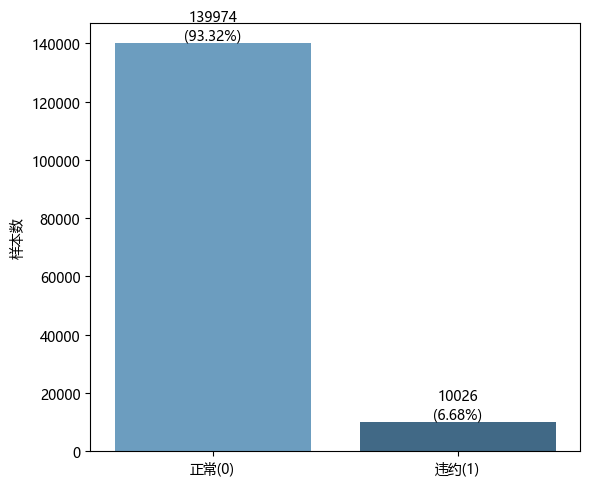

违约率: 6.68%


In [6]:
# ---- 标签分布（关键！严重不平衡） ----
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
target_col = "SeriousDlqin2yrs"

counts = train[target_col].value_counts().sort_index()
pcts = (counts / len(train) * 100).round(2)

plt.figure(figsize=(6, 5))
sns.barplot(x=["正常(0)", "违约(1)"], y=counts.values, palette="Blues_d")
plt.ylabel("样本数")
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    plt.text(i, c, f"{c}\n({p}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()

default_rate = train[target_col].mean()
print(f"违约率: {default_rate:.2%}")

标签分布严重不平衡！
正样本仅约6.7%，属于严重不平衡分类问题。
此处不能用准确率评估，必须用 AUC / PR曲线！

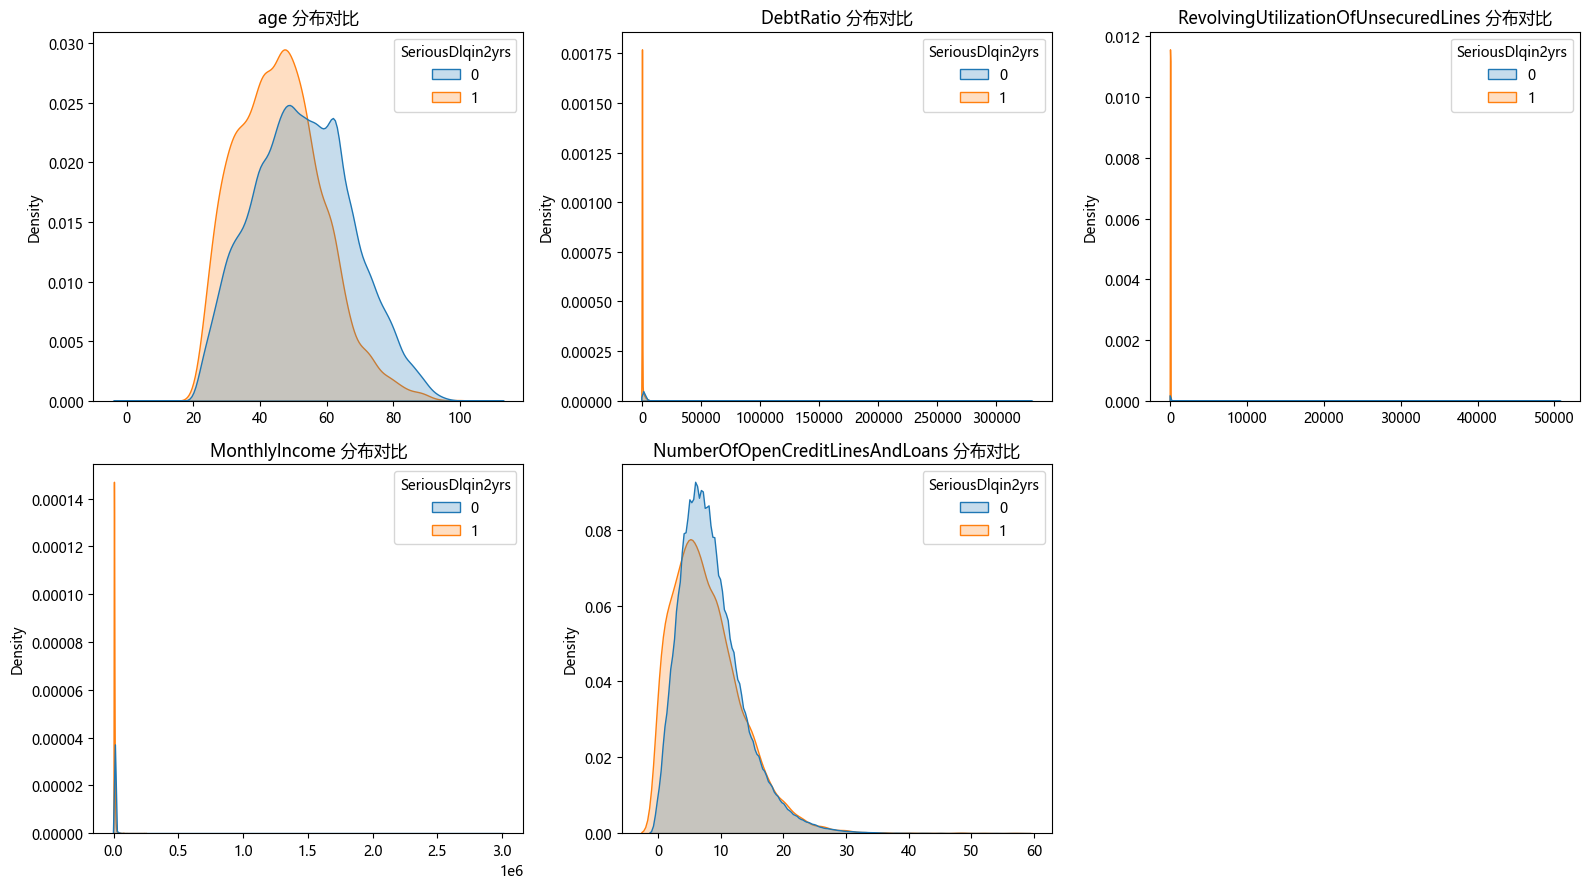

In [7]:
# ---- 关键特征对比：违约 vs 正常 的分布差异 ----
key_feat = ["age", "DebtRatio", "RevolvingUtilizationOfUnsecuredLines",
            "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, f in enumerate(key_feat):
    sns.kdeplot(data=train, x=f, hue=target_col, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f"{f} 分布对比")
    axes[i].set_xlabel("")
# 隐藏多余子图
for j in range(len(key_feat), 6):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

In [8]:
# ---- 缺失值分析 ----
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
pd.DataFrame({"缺失数量": missing, "缺失比例%": missing_pct})

print("MonthlyIncome 缺失约 20%，NumberDependents 有少量缺失，需重点处理")

MonthlyIncome 缺失约 20%，NumberDependents 有少量缺失，需重点处理


## 4. 数据清洗（缺失值 + 异常值）

企业级要点：**训练集与测试集用同一套清洗逻辑**，且每月收入缺失 20% 属于系统性能缺失，用**中位数**填充比均值更稳健。

In [9]:
# 建模特征列表（标签列 SeriousDlqin2yrs 单独取出）
FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfDependents",
]
# 从训练集计算统计量（防止数据泄漏至测试集）
monthly_median = train["MonthlyIncome"].median()
dependents_median = train["NumberOfDependents"].median()
cap_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]
caps = {c: train[c].quantile(0.99) for c in cap_cols}

def clean(df: pd.DataFrame, monthly_median, dependents_median, caps) -> pd.DataFrame:
    """统一清洗：缺失值 + 异常值剪裁（使用训练集统计量）。"""
    df = df.copy()
    # 月收入缺失 → 用训练集中位数填充
    df["MonthlyIncome"] = df["MonthlyIncome"].fillna(monthly_median)
    df["NumberOfDependents"] = df["NumberOfDependents"].fillna(dependents_median)
    # 异常值剪裁（Winsorize 到 99 分位，使用训练集分位点）
    for c in caps:
        df[c] = df[c].clip(upper=caps[c])
    # 清理不合理年龄
    df["age"] = df["age"].clip(lower=18, upper=100)
    return df

train_clean = clean(train, monthly_median, dependents_median, caps)
test_clean = clean(test, monthly_median, dependents_median, caps)

y = train_clean[target_col]
X = train_clean[FEATURES]
X_test = test_clean[FEATURES]


## 5. WOE 分箱与 IV 值特征筛选（企业风控的黄金做法）

风控场景几乎必用 **WOE（证据权重）+ IV（信息量）**：
- **WOE** 衡量“该分箱里违约 vs 正常的相对风险”，单调、线性化，天然适合逻辑回归。
- **IV > 0.1** 通常认为特征有较强预测力，据此筛选变量（同时规避多重共线性）。

我们这里用**等频分箱**近似 WOE，重点演示思路（建模时也可直接用 WOE 转换后的特征）。

In [10]:
def calc_woe_iv(x: pd.Series, target: pd.Series, bins: int = 10):
    """基于等频分箱粗略计算 WOE 与 IV。"""
    # 等频分箱
    try:
        cut, _ = pd.qcut(x, q=bins, duplicates="drop", retbins=True)
    except Exception:
        cut = pd.cut(x, bins=bins)

    df_tmp = pd.DataFrame({"x": cut, "y": target})
    good = df_tmp.groupby("x")["y"].count() - df_tmp.groupby("x")["y"].sum()  # 正常
    bad = df_tmp.groupby("x")["y"].sum()                                          # 违约
    good_pct = good / (target == 0).sum()
    bad_pct = bad / (target == 1).sum()
    # 平滑，避免除0
    good_pct = good_pct.clip(lower=1e-6)
    bad_pct = bad_pct.clip(lower=1e-6)
    woe = np.log(bad_pct / good_pct)
    iv = ((bad_pct - good_pct) * woe).sum()
    return woe, iv


iv_scores = {}
for f in FEATURES:
    _, iv = calc_woe_iv(X[f], y)
    iv_scores[f] = iv

iv_df = pd.DataFrame(iv_scores.items(), columns=["特征", "IV值"]).sort_values("IV值", ascending=False)

# IV 解释力划分
def iv_level(iv):
    if iv >= 0.5:  return "极强"
    if iv >= 0.1:  return "较强"
    if iv >= 0.02: return "一般"
    return "弱（建议剔除）"

iv_df["解释力"] = iv_df["IV值"].apply(iv_level)
iv_df

,特征,IV值,解释力
0,RevolvingUtilizationOfUnsecuredLines,1.1134,极强
2,NumberOfTime30-59DaysPastDueNotWorse,0.4718,较强
1,age,0.2592,较强
3,DebtRatio,0.0737,一般
4,MonthlyIncome,0.0670,一般
5,NumberOfOpenCreditLinesAndLoans,0.0669,一般
9,NumberOfDependents,0.0250,一般
7,NumberRealEstateLoansOrLines,0.0121,弱（建议剔除）
6,NumberOfTimes90DaysLate,0.0000,弱（建议剔除）
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,弱（建议剔除）


In [11]:
# ---- 筛选 IV >= 0.02 的特征用于建模（弱特征剔除，提升稳定性与可解释性） ----
keep_features = iv_df[iv_df["IV值"] >= 0.02]["特征"].tolist()
drop_features = [f for f in FEATURES if f not in keep_features]

print("保留特征:", keep_features)
print("剔除特征:", drop_features if drop_features else "无")

保留特征: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']
剔除特征: ['NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse']


## 6. 模型构建与类别不平衡处理

企业级要点：正样本仅 6.7%，对逻辑回归采用 **`class_weight='balanced'`**（自动加大少数类权重），配合 **分层交叉验证（StratifiedKFold）** 保证每个折里两类比例一致。

In [12]:
# ---- 划分训练 / 验证集（分层） ----
X_sel = X[keep_features]
X_test_sel = X_test[keep_features]

X_train, X_val, y_train, y_val = train_test_split(
    X_sel, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"建模训练集: {X_train.shape}, 验证集: {X_val.shape}")
print(f"训练集违约率: {y_train.mean():.2%}")

建模训练集: (120000, 7), 验证集: (30000, 7)
训练集违约率: 6.68%


In [13]:
# ---- 建模 Pipeline：标准化 + 逻辑回归（类别加权） ----
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        class_weight="balanced",   # 处理不平衡
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)
print("模型训练完成")

# 验证集概率预测
y_val_proba = model.predict_proba(X_val)[:, 1]

模型训练完成


In [14]:
# ---- 分层 K 折交叉验证 AUC ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(model, X_sel, y, cv=skf, scoring="roc_auc")
print(f"5折交叉验证 AUC: 均值={cv_auc.mean():.4f}  各折={np.round(cv_auc, 4)}")

5折交叉验证 AUC: 均值=0.8266  各折=[0.8243 0.8246 0.8354 0.8219 0.8268]


## 7. 模型评估

评价指标上路：**AUC（Rank指标，不受阈值影响）+ KS + 混淆矩阵 + PR 曲线**。

注意：因为类别不平衡，**不要只看准确率**——把所有客户都判为“正常”准确率也有 93%，但毫无用处。

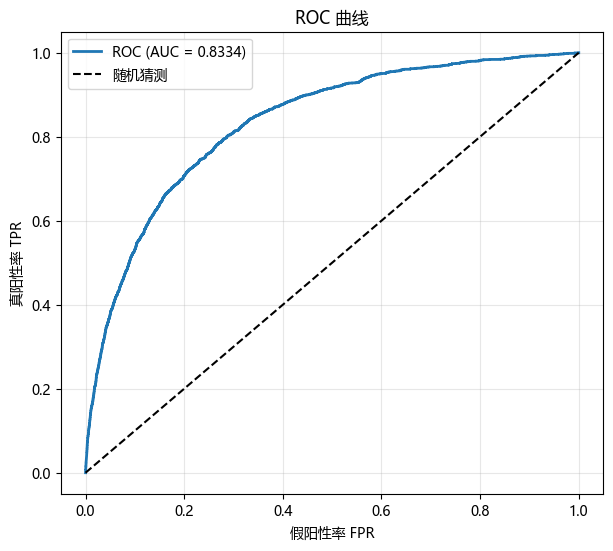

验证集 AUC: 0.8334
验证集 KS  : 0.5152  (>0.3 即为区分能力不错)


In [15]:
# ---- ROC 曲线 + AUC + KS ----
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
auc_score = roc_auc_score(y_val, y_val_proba)
ks = max(tpr - fpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_score:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="随机猜测")
plt.xlabel("假阳性率 FPR")
plt.ylabel("真阳性率 TPR")
plt.title("ROC 曲线")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"验证集 AUC: {auc_score:.4f}")
print(f"验证集 KS  : {ks:.4f}  (>0.3 即为区分能力不错)")

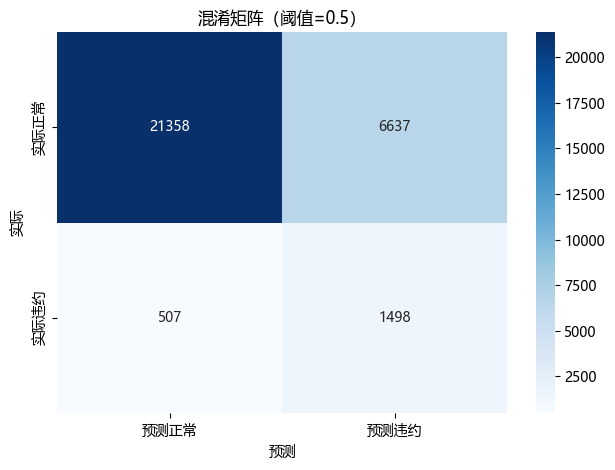

分类报告（阈值=0.5）:

              precision    recall  f1-score   support

          正常       0.98      0.76      0.86     27995
          违约       0.18      0.75      0.30      2005

    accuracy                           0.76     30000
   macro avg       0.58      0.76      0.58     30000
weighted avg       0.92      0.76      0.82     30000



In [16]:
# ---- 混淆矩阵（默认阈值0.5） ----
y_pred_default = (y_val_proba >= 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred_default)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["预测正常", "预测违约"],
            yticklabels=["实际正常", "实际违约"])
plt.title("混淆矩阵（阈值=0.5）")
plt.ylabel("实际")
plt.xlabel("预测")
plt.tight_layout()
plt.show()

print("分类报告（阈值=0.5）:\n")
print(classification_report(y_val, y_pred_default, target_names=["正常", "违约"]))

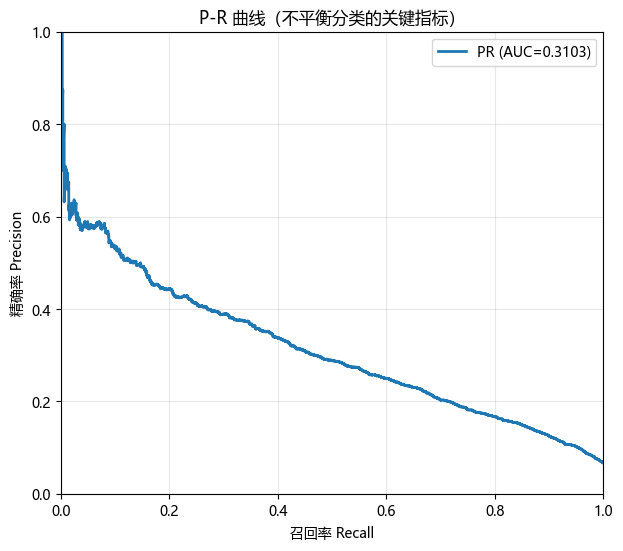

PR-AUC: 0.3103


In [17]:
# ---- PR 曲线（对不平衡问题比 ROC 更直观） ----
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, lw=2, label=f"PR (AUC={pr_auc:.4f})")
plt.xlabel("召回率 Recall")
plt.ylabel("精确率 Precision")
plt.title("P-R 曲线（不平衡分类的关键指标）")
plt.grid(alpha=0.3)
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print(f"PR-AUC: {pr_auc:.4f}")

## 8. 阈值调优 + 系数业务解读

**业务逻辑**：金融风控宁可错杀、不可放过。默认 0.5 的阈值保全了正常客户，但**漏了很多违约者**。把阈值调低（如 0.3）会提高召回（抓住更多违约），代价是也会误伤部分正常客户。

我们绘制 **Precision / Recall vs 阈值**，帮助决策。

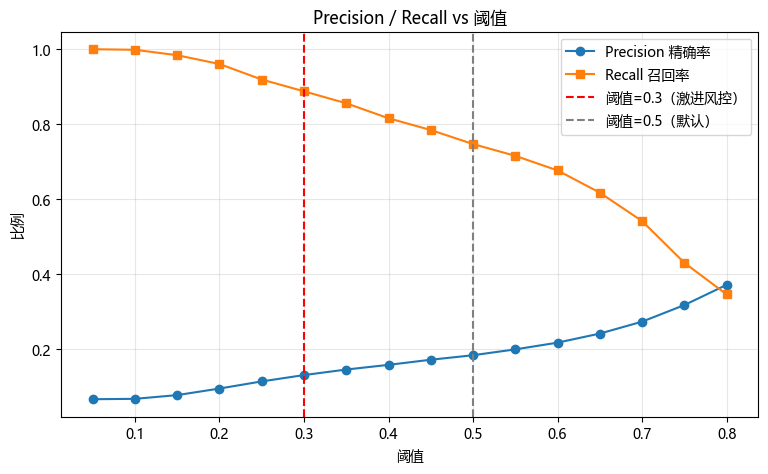

In [18]:
# ---- 阈值扫描：观察 Precision / Recall 随阈值变化 ----
thresholds = np.arange(0.05, 0.85, 0.05)
pr, rc = [], []
for t in thresholds:
    pred_t = (y_val_proba >= t).astype(int)
    pr.append(precision_score(y_val, pred_t, zero_division=0))
    rc.append(recall_score(y_val, pred_t))

plt.figure(figsize=(9, 5))
plt.plot(thresholds, pr, "o-", label="Precision 精确率")
plt.plot(thresholds, rc, "s-", label="Recall 召回率")
plt.axvline(0.3, color="red", linestyle="--", label="阈值=0.3（激进风控）")
plt.axvline(0.5, color="gray", linestyle="--", label="阈值=0.5（默认）")
plt.xlabel("阈值")
plt.ylabel("比例")
plt.title("Precision / Recall vs 阈值")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# ---- 演示：阈值从 0.5 降到 0.3 对风控的意义 ----
for t in [0.5, 0.3]:
    pred_t = (y_val_proba >= t).astype(int)
    detected = pred_t.sum()          # 被判为高风险的人数
    caught = (pred_t & y_val).sum()  # 其中真正违约的人数
    miss = (y_val == 1).sum() - caught  # 漏掉的违约人数
    print(f"阈值={t}: 标记高风险 {detected:,} 人 | 抓住违约 {caught:,} 人 | 漏掉违约 {miss:,} 人")

阈值=0.5: 标记高风险 8,135 人 | 抓住违约 1,498 人 | 漏掉违约 507 人
阈值=0.3: 标记高风险 13,564 人 | 抓住违约 1,780 人 | 漏掉违约 225 人


In [24]:
# ---- 逻辑回归系数业务解读（可解释性！） ----
# 系数 = 特征→Log(Odds) 的影响。正=提高违约概率，负=降低违约概率。
lr = model.named_steps["lr"]
coef_df = pd.DataFrame({
    "特征": keep_features,
    "系数": lr.coef_[0],
}).sort_values("系数", ascending=False)

# 转成 Odds 比率解释：exp(系数) = 特征每+1个标准差，违约几率的变化倍数
coef_df["Odds比(exp)"] = np.exp(coef_df["系数"])
coef_df

,特征,系数,Odds比(exp)
0,RevolvingUtilizationOfUnsecuredLines,0.8416,2.3201
1,NumberOfTime30-59DaysPastDueNotWorse,0.5237,1.6883
5,NumberOfOpenCreditLinesAndLoans,0.1397,1.1500
6,NumberOfDependents,0.0393,1.0401
3,DebtRatio,-0.0716,0.9309
4,MonthlyIncome,-0.1619,0.8506
2,age,-0.2697,0.7636


解读示例：Odds比 >1 → 该特征越高，违约概率越大；<1 → 越小。

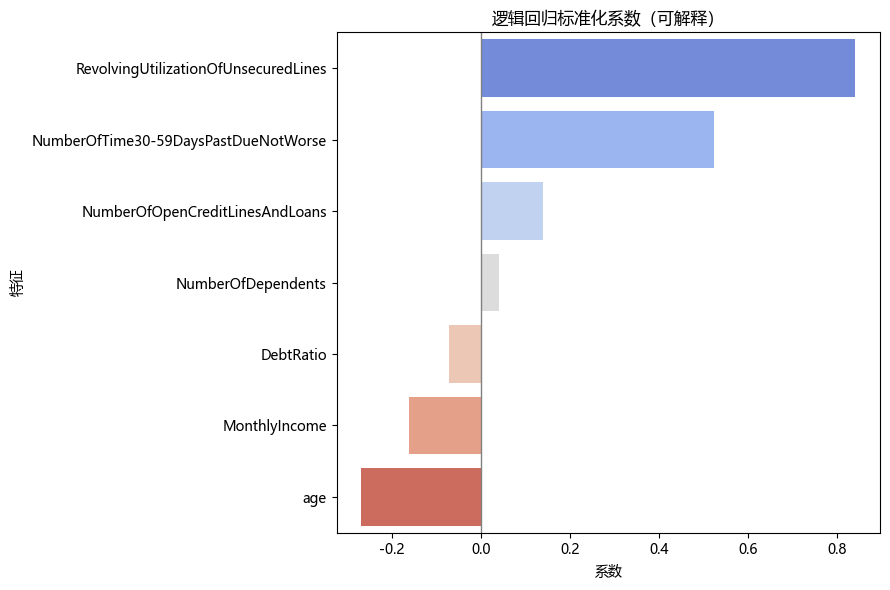

In [21]:
# 可视化系数（业务侧重点不同可调整）
plt.figure(figsize=(9, 6))
sns.barplot(x=coef_df["系数"], y=coef_df["特征"], palette="coolwarm")
plt.axvline(0, color="gray", linewidth=1)
plt.title("逻辑回归标准化系数（可解释）")
plt.tight_layout()
plt.show()

## 9. 预测并生成提交文件

在测试集上预测**违约概率**，输出与 `sampleEntry.csv` 格式一致的提交文件。

**提示**：这里默认输出概率即可（Kaggle 排名用 AUC，不依赖阈值）。实际业务中，你可用上面的阈值调优结果做二分类决策。

In [25]:
# ---- 预测测试集违约概率 ----
test_ids = sample[["Id"]]
y_test_proba = model.predict_proba(X_test_sel)[:, 1]

submission = pd.DataFrame({
    "Id": test_ids["Id"].values,
    "Probability": y_test_proba,
})

submission.head()

,Id,Probability
0,1,0.6409
1,2,0.4109
2,3,0.1927
3,4,0.5304
4,5,0.7692


In [26]:
# ---- 保存提交文件 ----
submission_path = os.path.join(DATA_DIR, "submission.csv")
submission.to_csv(submission_path, index=False)
print(f"已保存提交文件: {submission_path}")
print(f"提交行数: {len(submission)}（应与 sampleEntry 一致 = {len(sample)}）")

已保存提交文件: GiveMeSomeCredit-data\submission.csv
提交行数: 101503（应与 sampleEntry 一致 = 101503）


In [27]:
# ---- 项目总结 ----
print("=" * 60)
print("Give Me Some Credit 逻辑回归项目完成！")
print("=" * 60)
print(f"  5折交叉验证 AUC : {cv_auc.mean():.4f}")
print(f"  验证集 AUC      : {auc_score:.4f}")
print(f"  验证集 KS       : {ks:.4f}")
print(f"  提交文件        : {submission_path}")
print("=" * 60)
print("下一步优化方向: XGBoost/LightGBM(basket)、WOE正式分箱、过采样(SMOTE)、")
print("               概率校准、评分卡映射(Score = Offset + Factor·ln(Odds))")

Give Me Some Credit 逻辑回归项目完成！
  5折交叉验证 AUC : 0.8266
  验证集 AUC      : 0.8334
  验证集 KS       : 0.5152
  提交文件        : GiveMeSomeCredit-data\submission.csv
下一步优化方向: XGBoost/LightGBM(basket)、WOE正式分箱、过采样(SMOTE)、
               概率校准、评分卡映射(Score = Offset + Factor·ln(Odds))
